# Lab Project 4: Real Estate Sales

Please load `housing_price.csv`. The file includes the following variables:
- `SquareFeet`: Square feet of the house
- `Bedrooms`: # of bedrooms of the house
- `Bathrooms`: # of bathrooms of the house
- `Neighborhood`: Neighborhood classification
- `YearBuilt`: Year that the house was built
- `price`: House price

Please **clean the data**, making sure that:
- The capitalization in variables with text is harmonized
- There are no characters in otherwise numeric variables
- There are no duplicate rows in the dataset
- Any extreme outliers in numeric variables are replaced with the median

Finally, please analyze the data and come up with **3 insights** that are based, at least partially, on **mutated data*

For mutating data, do the following:
- Add a column,    house_ages(in years), that contains the age of the house** a  tthe  time of salesin   2022**
- Add  a column ,'old_house' that contains'old'' ifthe  house age is greater than 16 or 'young' otherwise).

**Save a file as 'housing_price_new.csv'**


Answer the following questions and include your final code below. When you are done, click on `Run` > `Restart Kernel and Run All Cells...` and verify the output.

- Q: What is the final number of rows in the cleaned dataset?
- A:  49653
- Q: Did you have to replace any extreme outliers? If so, in which variable(s)?
- A: Yes there were 38 outliers in the data for 'Price' varibale that were replaced with the median of the "price"
- Q: [After handling outliers] What is the average price of the house?
- A: 226064.77787847663
-  Q :What is the average age of the house)
- A: 36.61013433226593
- Q: How many ol/ young houses exist in the dataset? 
- A: old      39424
     young    10229
  
- Q: What is your 1st insight? (Answer in 1-3 sentences.)
- A: The housing market shows a stable, near-normal price distribution, indicating predictability in pricing trends.
  While there’s a slight skew towards higher-priced properties, the majority of homes are mid-range, primarily between 200,000 and $250,000.
  This suggests strong demand in the mid-market segment, making it an attractive focus for sales and marketing efforts.

  
- Q: What is your 2nd insight? (Answer in 1-3 sentences.)
- A:
  Strong correlation: 'SquareFeet' has a significant positive correlation (0.75) with 'Price', indicating that larger homes tend to have higher prices.
  Weak correlations: Other variables like 'Bedrooms' and 'Bathrooms' have weak correlations with 'Price' (0.07 and 0.03 respectively), suggesting they contribute less to price variations.
  Negative correlation: The slight negative correlation of 'house_ages (in years)' with 'Price' implies that newer homes may have slightly higher prices, but the relationship is minimal.

- Q: What is your 3rd insight? (Answer in 1-3 sentences.)
- A: The Suburb neighborhood is the most popular, with 16,607 listings, followed closely by Rural at 16,558 and Urban at 16,488.
   This indicates a fairly even distribution of properties across these three neighborhoods, suggesting that demand and market activity are well-distributed across different areas.
   Suburb remains slightly more favored, potentially indicating a preference for suburban living.



In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
HP=pd.read_csv('housing_price(1).csv')

In [5]:
HP

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,40145,1006,2,1,SUbURB,1973 year,$155
1,17217,1013,2,1,SuBURB,2018 year,$276
2,36236,1112,3,1,SUBuRb,1978 year,"$2,360"
3,29981,1005,3,3,uRBAN,1978 year,"$2,698"
4,23663,1256,3,1,RURAL,1978 year,"$3,001"
...,...,...,...,...,...,...,...
49652,7431,2758,five,2,RURAl,1967 year,"$492,195"
49653,30429,1481,2,3,SuBuRB,1982 year,"$50,642"
49654,18459,1303,2,1,rURAL,2007 year,"$50,900"
49655,20160,2931,4,1,rUraL,2008 year,"$433,866"


In [6]:
HP['Neighborhood']=HP['Neighborhood'].str.title()

In [7]:
HP['YearBuilt']=HP['YearBuilt'].str.replace(' year','', regex=False)

In [8]:
HP['Price']=HP['Price'].str.replace('[^0-9]','',regex=True)

In [9]:
HP

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,40145,1006,2,1,Suburb,1973,155
1,17217,1013,2,1,Suburb,2018,276
2,36236,1112,3,1,Suburb,1978,2360
3,29981,1005,3,3,Urban,1978,2698
4,23663,1256,3,1,Rural,1978,3001
...,...,...,...,...,...,...,...
49652,7431,2758,five,2,Rural,1967,492195
49653,30429,1481,2,3,Suburb,1982,50642
49654,18459,1303,2,1,Rural,2007,50900
49655,20160,2931,4,1,Rural,2008,433866


In [10]:
HP['Bedrooms'].value_counts()

Bedrooms
3       12571
4       12363
2       12314
5        9989
five     2420
Name: count, dtype: int64

In [11]:
HP['Bedrooms']=HP['Bedrooms'].str.replace('five','5', regex=False)

In [12]:
HP['Bedrooms'].value_counts()

Bedrooms
3    12571
5    12409
4    12363
2    12314
Name: count, dtype: int64

In [13]:
HP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49657 entries, 0 to 49656
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            49657 non-null  int64 
 1   SquareFeet    49657 non-null  int64 
 2   Bedrooms      49657 non-null  object
 3   Bathrooms     49657 non-null  int64 
 4   Neighborhood  49657 non-null  object
 5   YearBuilt     49657 non-null  object
 6   Price         49657 non-null  object
dtypes: int64(3), object(4)
memory usage: 2.7+ MB


In [14]:
HP['Bedrooms']=pd.to_numeric(HP['Bedrooms'])

In [15]:
HP['YearBuilt']=pd.to_numeric(HP['YearBuilt'])

In [16]:
HP['Price']=pd.to_numeric(HP['Price'])

In [17]:
HP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49657 entries, 0 to 49656
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            49657 non-null  int64 
 1   SquareFeet    49657 non-null  int64 
 2   Bedrooms      49657 non-null  int64 
 3   Bathrooms     49657 non-null  int64 
 4   Neighborhood  49657 non-null  object
 5   YearBuilt     49657 non-null  int64 
 6   Price         49657 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 2.7+ MB


In [18]:
HP[HP.duplicated()]

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
49653,30429,1481,2,3,Suburb,1982,50642
49654,18459,1303,2,1,Rural,2007,50900
49655,20160,2931,4,1,Rural,2008,433866
49656,40028,2620,2,3,Urban,2002,433964


In [19]:
HP=HP.drop_duplicates()

In [20]:
HP[HP.duplicated()]

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price


In [21]:
HP

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,40145,1006,2,1,Suburb,1973,155
1,17217,1013,2,1,Suburb,2018,276
2,36236,1112,3,1,Suburb,1978,2360
3,29981,1005,3,3,Urban,1978,2698
4,23663,1256,3,1,Rural,1978,3001
...,...,...,...,...,...,...,...
49648,21816,2998,3,2,Urban,1995,468494
49649,3785,2901,2,3,Urban,1996,470990
49650,26931,2995,5,2,Urban,1954,476672
49651,46611,2957,5,1,Suburb,2001,482577


In [22]:
HP['house_ages(in years)']=2022-HP['YearBuilt']

/var/folders/_4/b9s2hms900bfwkkw9c61rv4w0000gn/T/ipykernel_95577/805268661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HP['house_ages(in years)']=2022-HP['YearBuilt']


In [23]:
HP

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years)
0,40145,1006,2,1,Suburb,1973,155,49
1,17217,1013,2,1,Suburb,2018,276,4
2,36236,1112,3,1,Suburb,1978,2360,44
3,29981,1005,3,3,Urban,1978,2698,44
4,23663,1256,3,1,Rural,1978,3001,44
...,...,...,...,...,...,...,...,...
49648,21816,2998,3,2,Urban,1995,468494,27
49649,3785,2901,2,3,Urban,1996,470990,26
49650,26931,2995,5,2,Urban,1954,476672,68
49651,46611,2957,5,1,Suburb,2001,482577,21


In [24]:
bins=[0,16,float('inf')]

In [25]:
labels=['young', 'old']

In [26]:
HP['Old_house']=pd.cut(HP['house_ages(in years)'],bins=bins, labels=labels, right=False)

/var/folders/_4/b9s2hms900bfwkkw9c61rv4w0000gn/T/ipykernel_95577/2752282052.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HP['Old_house']=pd.cut(HP['house_ages(in years)'],bins=bins, labels=labels, right=False)


In [27]:
HP

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years),Old_house
0,40145,1006,2,1,Suburb,1973,155,49,old
1,17217,1013,2,1,Suburb,2018,276,4,young
2,36236,1112,3,1,Suburb,1978,2360,44,old
3,29981,1005,3,3,Urban,1978,2698,44,old
4,23663,1256,3,1,Rural,1978,3001,44,old
...,...,...,...,...,...,...,...,...,...
49648,21816,2998,3,2,Urban,1995,468494,27,old
49649,3785,2901,2,3,Urban,1996,470990,26,old
49650,26931,2995,5,2,Urban,1954,476672,68,old
49651,46611,2957,5,1,Suburb,2001,482577,21,old


In [28]:
HP['Old_house'].value_counts()

Old_house
old      39424
young    10229
Name: count, dtype: int64

In [29]:
Q1_house_age = HP['house_ages(in years)'].quantile(0.25)
Q3_house_age = HP['house_ages(in years)'].quantile(0.75)
IQR_house_age = Q3_house_age - Q1_house_age
lower_bound=Q1_house_age-1.5*IQR_house_age
upper_bound=Q3_house_age+1.5*IQR_house_age

In [30]:
HP[(HP['house_ages(in years)']<lower_bound)|(HP['house_ages(in years)']>upper_bound)]

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years),Old_house


In [31]:
Q1_SquareFeet = HP['SquareFeet'].quantile(0.25)
Q3_SquareFeet = HP['SquareFeet'].quantile(0.75)
IQR_SquareFeet = Q3_SquareFeet - Q1_SquareFeet
lower_bound=Q1_SquareFeet-1.5*IQR_SquareFeet
upper_bound=Q3_SquareFeet+1.5*IQR_SquareFeet

In [32]:
HP[(HP['SquareFeet']<lower_bound)|(HP['SquareFeet']>upper_bound)]

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years),Old_house


In [33]:
Q1_Bedrooms = HP['Bedrooms'].quantile(0.25)
Q3_Bedrooms = HP['Bedrooms'].quantile(0.75)
IQR_Bedrooms = Q3_Bedrooms- Q1_Bedrooms
lower_bound=Q1_Bedrooms-1.5*IQR_Bedrooms
upper_bound=Q3_Bedrooms+1.5*IQR_Bedrooms

In [34]:
HP[(HP['Bedrooms']<lower_bound)|(HP['Bedrooms']>upper_bound)]

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years),Old_house


In [35]:
Q1_Bathrooms = HP['Bathrooms'].quantile(0.25)
Q3_Bathrooms = HP['Bathrooms'].quantile(0.75)
IQR_Bathrooms = Q3_Bathrooms- Q1_Bathrooms
lower_bound=Q1_Bathrooms-1.5*IQR_Bathrooms
upper_bound=Q3_Bathrooms+1.5*IQR_Bathrooms

In [36]:
HP[(HP['Bathrooms']<lower_bound)|(HP['Bathrooms']>upper_bound)]

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years),Old_house


In [37]:
Q1_Price = HP['Price'].quantile(0.25)
Q3_Price = HP['Price'].quantile(0.75)
IQR_Price = Q3_Price - Q1_Price
lower_bound = Q1_Price - 1.5 * IQR_Price
upper_bound = Q3_Price + 1.5 * IQR_Price

In [38]:
HP[(HP['Price']<lower_bound)|(HP['Price']>upper_bound)]

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years),Old_house
0,40145,1006,2,1,Suburb,1973,155,49,old
1,17217,1013,2,1,Suburb,2018,276,4,young
2,36236,1112,3,1,Suburb,1978,2360,44,old
3,29981,1005,3,3,Urban,1978,2698,44,old
4,23663,1256,3,1,Rural,1978,3001,44,old
5,27301,1041,4,1,Urban,2002,3927,20,old
49621,36804,2965,5,3,Rural,1960,442921,62,old
49622,26025,2985,4,1,Suburb,1959,443335,63,old
49623,8688,2883,2,3,Suburb,1978,444972,44,old
49624,29045,2205,4,2,Suburb,1967,445343,55,old


In [39]:
Median=HP['Price'].median()

In [40]:
Median

225690.0

In [41]:
HP['Price'] = np.where((HP['Price'] < lower_bound) | (HP['Price'] > upper_bound), Median,HP['Price'])

/var/folders/_4/b9s2hms900bfwkkw9c61rv4w0000gn/T/ipykernel_95577/505466063.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HP['Price'] = np.where((HP['Price'] < lower_bound) | (HP['Price'] > upper_bound), Median,HP['Price'])


In [42]:
HP[(HP['Price']<lower_bound)|(HP['Price']>upper_bound)]

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years),Old_house


In [43]:
Q1 = HP['house_ages(in years)'].quantile(0.25)
Q3 = HP['house_ages(in years)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [44]:
HP[(HP['house_ages(in years)']<lower_bound)|(HP['house_ages(in years)']>upper_bound)]

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years),Old_house


In [45]:
HP.isna().sum()

id                      0
SquareFeet              0
Bedrooms                0
Bathrooms               0
Neighborhood            0
YearBuilt               0
Price                   0
house_ages(in years)    0
Old_house               0
dtype: int64

In [46]:
HP.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49653 entries, 0 to 49652
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id                    49653 non-null  int64   
 1   SquareFeet            49653 non-null  int64   
 2   Bedrooms              49653 non-null  int64   
 3   Bathrooms             49653 non-null  int64   
 4   Neighborhood          49653 non-null  object  
 5   YearBuilt             49653 non-null  int64   
 6   Price                 49653 non-null  float64 
 7   house_ages(in years)  49653 non-null  int64   
 8   Old_house             49653 non-null  category
dtypes: category(1), float64(1), int64(6), object(1)
memory usage: 3.5+ MB


In [47]:
HP.to_csv('housing_price_new.csv', index=False)

In [48]:
HPN=pd.read_csv('housing_price_new.csv')

In [49]:
HPN

,id,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,house_ages(in years),Old_house
0,40145,1006,2,1,Suburb,1973,225690.0,49,old
1,17217,1013,2,1,Suburb,2018,225690.0,4,young
2,36236,1112,3,1,Suburb,1978,225690.0,44,old
3,29981,1005,3,3,Urban,1978,225690.0,44,old
4,23663,1256,3,1,Rural,1978,225690.0,44,old
...,...,...,...,...,...,...,...,...,...
49648,21816,2998,3,2,Urban,1995,225690.0,27,old
49649,3785,2901,2,3,Urban,1996,225690.0,26,old
49650,26931,2995,5,2,Urban,1954,225690.0,68,old
49651,46611,2957,5,1,Suburb,2001,225690.0,21,old


In [50]:
HPN.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49653 entries, 0 to 49652
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    49653 non-null  int64  
 1   SquareFeet            49653 non-null  int64  
 2   Bedrooms              49653 non-null  int64  
 3   Bathrooms             49653 non-null  int64  
 4   Neighborhood          49653 non-null  object 
 5   YearBuilt             49653 non-null  int64  
 6   Price                 49653 non-null  float64
 7   house_ages(in years)  49653 non-null  int64  
 8   Old_house             49653 non-null  object 
dtypes: float64(1), int64(6), object(2)
memory usage: 3.4+ MB


In [51]:
HPN['Price'].isna().sum()

0

In [52]:
HPN['Price'].nunique()

45495

<Axes: xlabel='Price', ylabel='Count'>

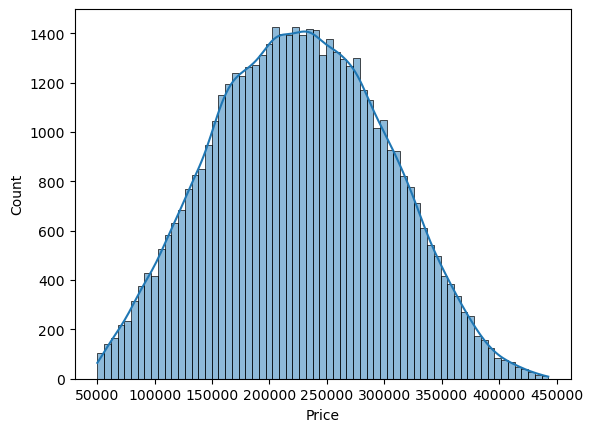

In [109]:
sns.histplot(HPN['Price'], kde=True)

In [53]:
CM = HPN.select_dtypes('number').corr()
CM

,id,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,house_ages(in years)
id,1.000000,-0.004193,-0.004226,0.001375,-0.005274,-0.002686,0.005274
SquareFeet,-0.004193,1.000000,-0.005367,-0.004201,0.001389,0.747226,-0.001389
Bedrooms,-0.004226,-0.005367,1.000000,0.007259,0.003233,0.069226,-0.003233
Bathrooms,0.001375,-0.004201,0.007259,1.000000,0.003879,0.027132,-0.003879
YearBuilt,-0.005274,0.001389,0.003233,0.003879,1.000000,-0.000179,-1.000000
Price,-0.002686,0.747226,0.069226,0.027132,-0.000179,1.000000,0.000179
house_ages(in years),0.005274,-0.001389,-0.003233,-0.003879,-1.000000,0.000179,1.000000


<Axes: >

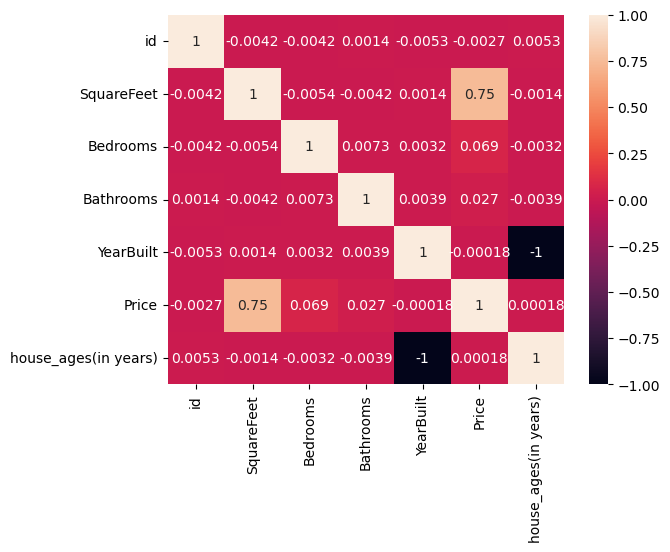

In [54]:
sns.heatmap(CM, annot=True)

In [111]:
HPN['Neighborhood'].value_counts()

Neighborhood
Suburb    16607
Rural     16558
Urban     16488
Name: count, dtype: int64